In [2]:
import yfinance as yf #the asked liberary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor #using the random forest model
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
ticker_symbol = "AAPL"
print(f"Fetching data for {ticker_symbol}...")

# Fetch 5 years of data
data = yf.download(ticker_symbol, start="2019-01-01", end=None)

# Display the first few rows
data.head()

Fetching data for AAPL...


/tmp/ipykernel_12072/1716388414.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker_symbol, start="2019-01-01", end=None)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503727,37.724590,36.627404,36.784146,148158800
2019-01-03,33.768074,34.606398,33.722951,34.193172,365248800
2019-01-04,35.209614,35.278487,34.150430,34.323794,234428400
2019-01-07,35.131252,35.344992,34.649157,35.314117,219111200
2019-01-08,35.800961,36.055072,35.271369,35.518352,164101200


In [11]:
# Select features
df = data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Predict the NEXT day's closing price
df['Target'] = df['Close'].shift(-1)

# Remove the last row (it has no 'next day' to predict yet)
df.dropna(inplace=True)

# Define X (Input) and y (Output)
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

print("Data prepared. Features shape:", X.shape)

Data prepared. Features shape: (1847, 4)


In [12]:
# Chronological split for time-series
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Initialize and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model training complete.")


Model training complete.


In [13]:
# Make predictions
predictions = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 506.65
R-squared Score: 0.26


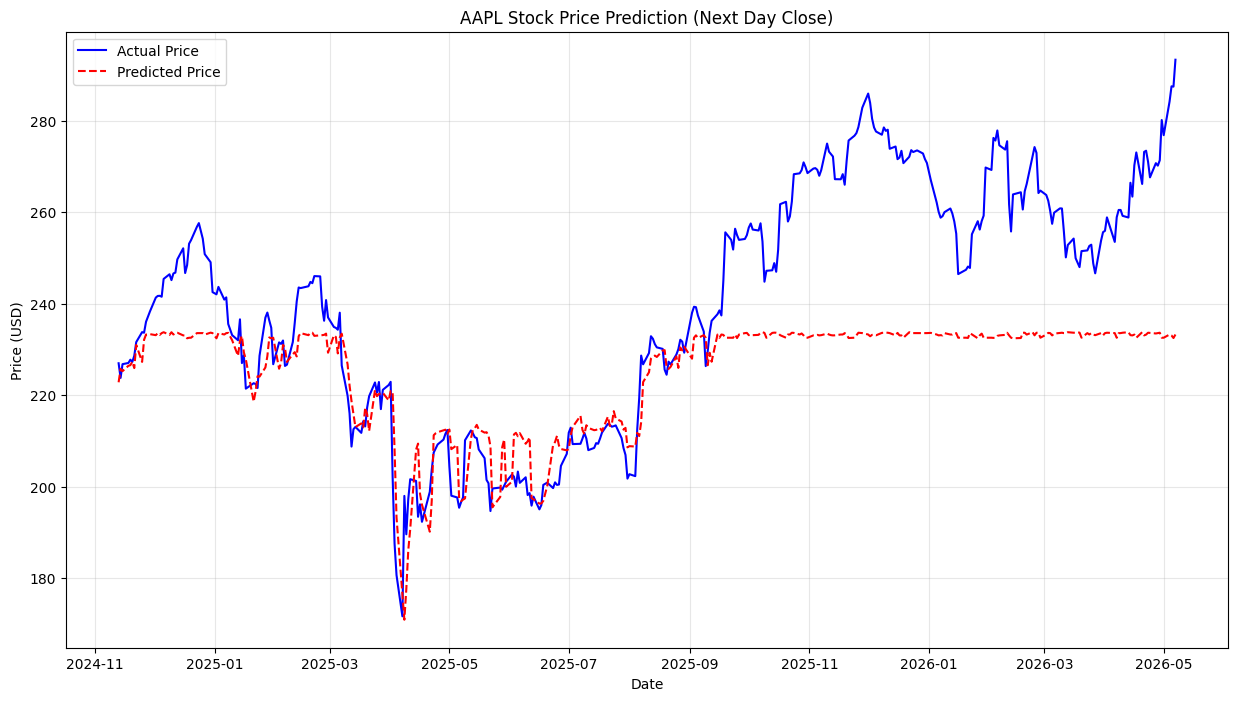

In [14]:
plt.figure(figsize=(15, 8))
plt.plot(df.index[split_index:], y_test, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(df.index[split_index:], predictions, label='Predicted Price', color='red', linestyle='--', linewidth=1.5)

plt.title(f'{ticker_symbol} Stock Price Prediction (Next Day Close)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# Get the most recent data point available
latest_features = X.tail(1)
tomorrow_prediction = model.predict(latest_features)

print(f"--- PREDICTION FOR NEXT TRADING DAY ---")
print(f"Based on the latest data, the predicted closing price for {ticker_symbol} is: ${tomorrow_prediction[0]:.2f}")

--- PREDICTION FOR NEXT TRADING DAY ---
Based on the latest data, the predicted closing price for AAPL is: $233.26
